<a href="https://colab.research.google.com/github/Emil-888/Data-Science/blob/main/Copia_de_Copia_de_Copia_de_Clase__16_K_Means_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science
_________________________________
Clase: 16  
Tema: K-Means (versión extendida)
_________________________________

Este notebook es una guía **paso a paso** y **extensa** del algoritmo K-Means: intuición, matemática básica, práctica con datos artificiales, hiperparámetros, métricas para elegir `k`, limitaciones y ejercicios.



## Objetivo de la clase

Al terminar este notebook deberías poder:

1. Explicar con tus palabras **qué hace K-Means** y qué optimiza.
2. Generar datos de prueba con `make_blobs`, `make_moons` y `make_circles`.
3. Entrenar `KMeans`, interpretar **centroides**, **etiquetas** e **inercia**.
4. Visualizar **regiones de decisión** (Voronoi).
5. Entender el impacto de `init`, `n_init`, `max_iter` y `random_state`.
6. Elegir `k` con **método del codo** y **silhouette**.
7. Reconocer cuándo K-Means **falla** (formas no esféricas, escalas distintas, anisotropía, outliers).
8. Aplicar el flujo completo a datasets clásicos y a un caso de segmentación.

---

## Índice

1. [Qué es clustering y qué es K-Means](#teoria)
2. [Imports y configuración](#imports)
3. [Datos artificiales con `make_blobs`](#2)
4. [Primer modelo: anatomía de `KMeans`](#3)
5. [Variando k](#3b)
6. [Regiones de decisión](#4)
7. [Hiperparámetros en profundidad](#5)
8. [Limitaciones con `make_moons`](#6)
9. [Más ejemplos prácticos](#8)
10. [Laboratorio extendido](#lab)
11. [Datasets clásicos (Iris / Wine)](#clasicos)
12. [Caso de negocio: segmentación](#negocio)
13. [Ejercicios integradores](#ejercicios)
14. [Cheatsheet y reflexión final](#7)



<a name="teoria"></a>
## 1. Qué es clustering y qué es K-Means

### 1.1 Aprendizaje no supervisado

En **clasificación** tenemos etiquetas (`y`). En **clustering** no: el algoritmo debe descubrir estructura en `X`.

Casos de uso típicos:
- Segmentación de clientes
- Agrupar documentos / imágenes
- Detectar perfiles de comportamiento
- Compresión / cuantización de colores (idea clásica de K-Means)

### 1.2 Intuición de K-Means

K-Means parte de una hipótesis fuerte:

> “Los datos se agrupan en **k bolas** (grupos convexos/esféricos) alrededor de un centro.”

El algoritmo busca **k centroides** $\mu_1, \ldots, \mu_k$ y asigna cada punto al centroide más cercano.

### 1.3 Algoritmo (pasos)

1. Elegir `k`.
2. Inicializar centroides (al azar o con `k-means++`).
3. **Asignación**: cada punto $x_i$ va al cluster del centroide más cercano.
4. **Actualización**: cada centroide se recalcula como la media de sus puntos.
5. Repetir 3–4 hasta estabilizar (o llegar a `max_iter`).

### 1.4 Qué optimiza (inercia)

K-Means minimiza la **inercia** (Within-Cluster Sum of Squares, WCSS):

$$
J = \sum_{j=1}^{k} \sum_{x \in C_j} \| x - \mu_j \|^2
$$

Interpretación: “¿qué tan compactos son los clusters?”

Importante:
- Más `k` ⇒ inercia **siempre** tiende a bajar (en el límite, k = n puntos ⇒ inercia 0).
- Por eso no alcanza mirar solo “la inercia más chica”.

### 1.5 Supuestos y limitaciones (resumen temprano)

K-Means asume, en la práctica:
- Número de clusters conocido o estimable (`k`)
- Clusters más o menos **esféricos** y de **varianza similar**
- Features en escalas comparables (o estandarizadas)
- Poca sensibilidad a outliers (los outliers **sí** mueven el centroide)

Cuando eso no se cumple, el resultado puede verse “bonito”… pero ser conceptualmente incorrecto.



### 1.6 Pseudocódigo (para anclar la idea)

```text
inicializar centroides μ1..μk
repetir hasta convergencia:
    para cada punto x:
        asignar x al cluster j con ||x - μj|| mínimo
    para cada cluster j:
        μj = promedio de los puntos asignados a j
```

En scikit-learn esto está encapsulado en `KMeans.fit` / `fit_predict`.



<a name="imports"></a>
## 2. Imports y configuración inicial

Vamos a importar todo lo que usaremos a lo largo del notebook (datasets, métricas, escalado y visualización).

Si más adelante ves un `NameError`, volvé a ejecutar esta sección.



In [ ]:
# --- Datasets ---
from sklearn.datasets import make_blobs, make_moons, make_circles

# --- Modelo y utilidades ---
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from sklearn.preprocessing import StandardScaler

# --- Númerico / tablas ---
import numpy as np
import pandas as pd

# --- Plots ---
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — habilita proyección 3D

# Estilo liviano y reproducible
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False
np.set_printoptions(precision=3, suppress=True)

print("Imports OK")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)



Imports OK
NumPy: 2.1.3
pandas: 2.2.3


### 2.1 Mirada rápida a la API de `KMeans`

`help(KMeans)` muestra todos los hiperparámetros. Los más importantes para esta clase:

| Parámetro | Rol |
|---|---|
| `n_clusters` | cantidad de grupos `k` |
| `init` | `'k-means++'` (default) o `'random'` |
| `n_init` | cuántas veces reinicia y se queda con la mejor inercia |
| `max_iter` | máximo de iteraciones por inicialización |
| `tol` | tolerancia de convergencia |
| `random_state` | semilla para reproducibilidad |

Atributos útiles después de `fit`:
- `labels_` / resultado de `predict`
- `cluster_centers_`
- `inertia_`
- `n_iter_`



In [ ]:
help(KMeans)

Help on class KMeans in module sklearn.cluster._kmeans:

class KMeans(_BaseKMeans)
 |  KMeans(
 |      n_clusters=8,
 |      *,
 |      init='k-means++',
 |      n_init='auto',
 |      max_iter=300,
 |      tol=0.0001,
 |      verbose=0,
 |      random_state=None,
 |      copy_x=True,
 |      algorithm='lloyd'
 |  )
 |
 |  K-Means clustering.
 |
 |  Read more in the :ref:`User Guide <k_means>`.
 |
 |  Parameters
 |  ----------
 |
 |  n_clusters : int, default=8
 |      The number of clusters to form as well as the number of
 |      centroids to generate.
 |
 |      For an example of how to choose an optimal value for `n_clusters` refer to
 |      :ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.
 |
 |  init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
 |      Method for initialization:
 |
 |      * 'k-means++' : selects initial cluster centroids using sampling             based on an empiric

### 2.2 Relación entre `n_init` y `random_state`

- **`n_init`**: cuántas inicializaciones distintas se prueban. El modelo se queda con la de **menor inercia**.
- **`random_state`**: fija la semilla del generador aleatorio ⇒ mismas inicializaciones entre corridas.

Buen hábito de clase / producción educativa:
```python
KMeans(n_clusters=k, n_init=10, random_state=42)
```

Si `random_state=None` y `n_init=1`, podés ver resultados distintos cada vez.



<a name="2"></a>
## 3. Generación de datos artificiales con `make_blobs`

### 3.1 ¿Para qué sirve `make_blobs`?

`make_blobs` genera puntos alrededor de centros gaussianos. Es ideal para **probar clustering** porque controlamos:

- `n_samples`: cantidad de puntos
- `centers`: cantidad (o coordenadas) de centros reales
- `cluster_std`: dispersión (ruido / solapamiento)
- `random_state`: reproducibilidad

> No es un dataset “real”, pero permite ver el comportamiento del algoritmo con verdad conocida (`y`).



In [ ]:
# Dataset base de la clase: 5 grupos, algo de solapamiento
x, y = make_blobs(
    n_samples=500,
    centers=5,
    cluster_std=1.8,
    random_state=42,

)

print("Shape en x:", x.shape)
print("Shape en y:", y.shape)
print("Cluster reales unicos", np.unique(y))
print("Primeras 5 filas de x:", x[:5])
print("Primeras 5 ETIQUETAS DE Y:", y[:5])


Shape en x: (500, 2)
Shape en y: (500,)
Cluster reales unicos [0 1 2 3 4]
Primeras 5 filas de x: [[  4.618   0.358]
 [  1.861   6.754]
 [ -0.282   5.732]
 [ -1.194   0.129]
 [-10.247  -7.513]]
Primeras 5 ETIQUETAS DE Y: [1 4 4 1 2]


### 3.2 Exploración visual: sin etiquetas vs con etiquetas

En un problema real **no** verías colores de `y`. Primero miramos el “caos” sin etiquetas; después revelamos la estructura verdadera.



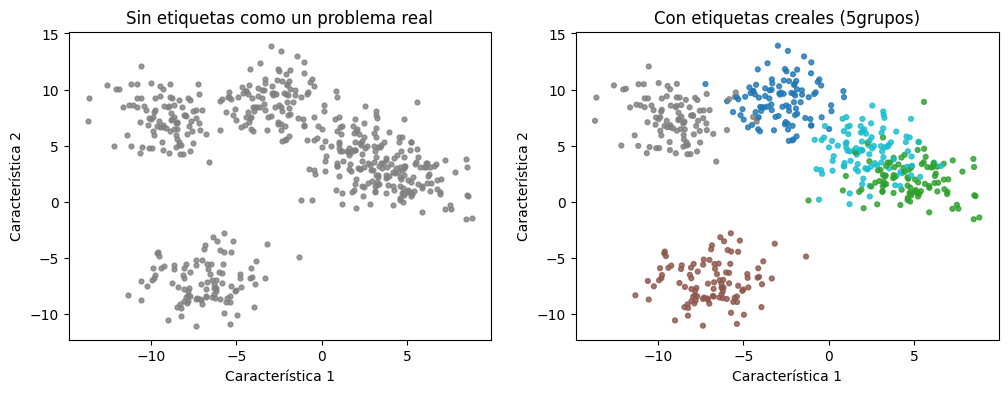

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x[:, 0], x[:, 1], s=12, alpha=0.8, c='gray')
axes[0].set_title("Sin etiquetas como un problema real")
axes[0].set_xlabel("Característica 1")
axes[0].set_ylabel("Característica 2")

axes[1].scatter(x[:, 0], x[:, 1], s=12, alpha=0.8, c=y, cmap='tab10')
axes[1].set_title("Con etiquetas creales (5grupos)")
axes[1].set_xlabel("Característica 1")
axes[1].set_ylabel("Característica 2")

plt.show()

### 3.3 Estadísticos por cluster real

Antes de modelar, conviene mirar medias y tamaños. Esto ancla la idea de “centroide = promedio del grupo”.



                n  media_feat1  media_feat2  std_feat1  std_feat2
cluster_real                                                     
0             100        -2.75         9.06       1.54       1.79
1             100         4.80         2.03       1.88       1.67
2             100        -6.88        -7.09       1.83       1.81
3             100        -8.98         7.44       1.79       1.80
4             100         2.29         4.45       1.62       1.84


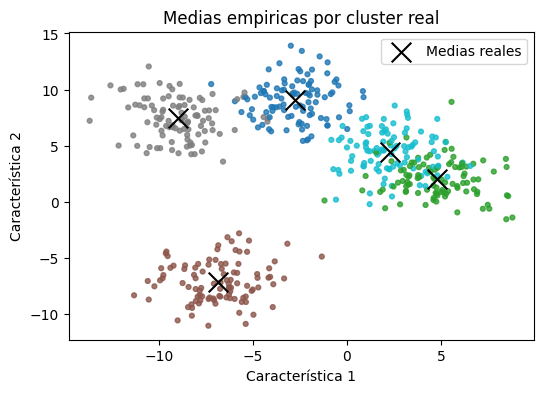

In [ ]:
df_blobs = pd.DataFrame(x, columns=['feat1', 'feat2'])
df_blobs["cluster_real"] = y

resumen = (
    df_blobs.groupby("cluster_real")
    .agg(
        n = ('feat1', 'size'),
        media_feat1 = ('feat1', 'mean'),
        media_feat2 = ('feat2', 'mean'),
        std_feat1 = ('feat1', 'std'),
        std_feat2 = ('feat2', 'std'),
    )
    .round(2)
  )
print(resumen)

#Centros verdades aproximado = medias por grupo
centros_reales = resumen [['media_feat1', 'media_feat2']].to_numpy()

plt.figure(figsize=(6, 4))
plt.scatter(x[:, 0], x[:, 1], s=12, alpha=0.8, c=y, cmap='tab10')
plt.scatter(
    centros_reales[:,0],
    centros_reales[:,1],
    c="black",
    s=200,
    marker="x",
    label="Medias reales",
)
plt.title("Medias empiricas por cluster real")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()


### 3.4 Sensibilidad a `cluster_std`

Si aumentamos la dispersión, los grupos se solapan y K-Means lo tiene más difícil (aunque `k` sea el correcto).



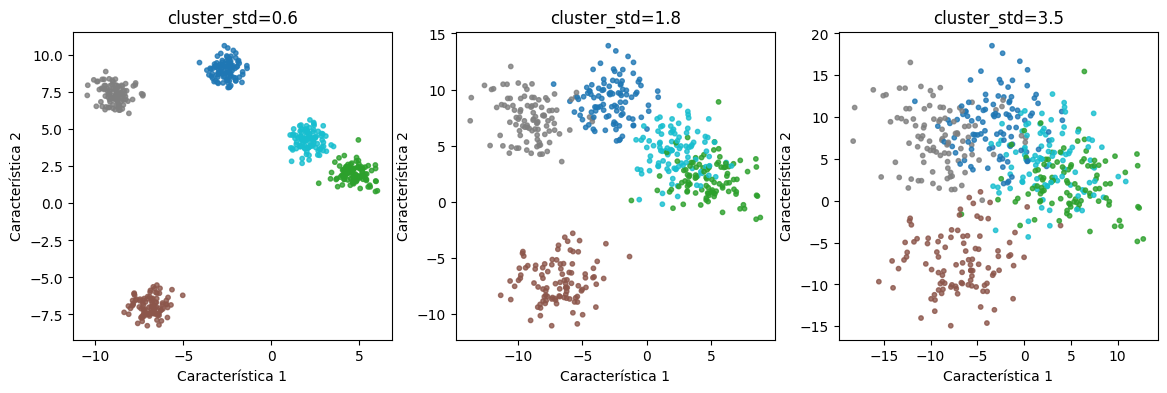

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, std in zip(axes, [0.6, 1.8, 3.5]):
  xs, ys = make_blobs(
    n_samples=500,
    centers=5,
    cluster_std=std,
    random_state=42,)
  ax.scatter(xs[:, 0], xs[:, 1], s=10, cmap='tab10', alpha=0.8, c=ys)
  ax.set_title(f"cluster_std={std}")
  ax.set_xlabel("Característica 1")
  ax.set_ylabel("Característica 2")
plt.show()



### 3.5 Mini experimento guiado

Cambiá `centers` y `cluster_std` abajo. Preguntas:
1. ¿Se siguen viendo grupos claros?
2. ¿Cuántos grupos “a ojo” dirías que hay?
3. ¿Eso coincide con el `centers` que pusiste?



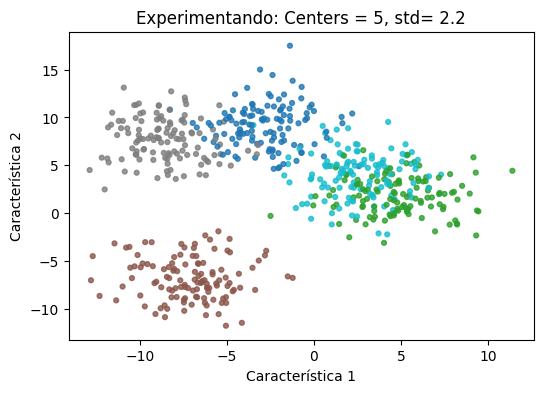

Conteo de cluster:
0    120
1    120
2    120
3    120
4    120
Name: count, dtype: int64


In [ ]:
centers_exp = 5
std_exp = 2.2
n_exp=600

x_exp, y_exp = make_blobs(
    n_samples=n_exp,
    centers=centers_exp,
    cluster_std=std_exp,
    random_state=42,
)

plt.figure(figsize=(6, 4))
plt.scatter(x_exp[:, 0], x_exp[:, 1], s=12, alpha=0.8, c=y_exp, cmap='tab10')
plt.title(f"Experimentando: Centers = {centers_exp}, std= {std_exp}")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()
print("Conteo de cluster:")
print(pd.Series(y_exp).value_counts().sort_index())

<a name="3"></a>
## 4. Primer modelo: anatomía de `KMeans`

Vamos a ir **muy despacio** con `k=1` para entender atributos, y después generalizar.



### 4.1 Caso extremo: k = 1

Con un solo cluster, el centroide debería ser aproximadamente la **media global** de `X`.



In [ ]:
kmeans_1 = KMeans(n_clusters=1, n_init = 10, random_state=42)
kmeans_1.fit(x)
print("Etiquetas (todas 0):", np.unique(kmeans_1.labels_))
print("Centroide aprendido:", kmeans_1.cluster_centers_)
print("Media global de x:", x.mean(axis=0))
print("Inercia:", round(kmeans_1.inertia_, 2))
print("Interciones:", kmeans_1.n_iter_)

pred = kmeans_1.predict(x)
print("Labels == predict(x)", np.array_equal(kmeans_1.labels_, pred))

Etiquetas (todas 0): [0]
Centroide aprendido: [[-2.304  3.179]]
Media global de x: [-2.304  3.179]
Inercia: 32922.93
Interciones: 2
Labels == predict(x) True


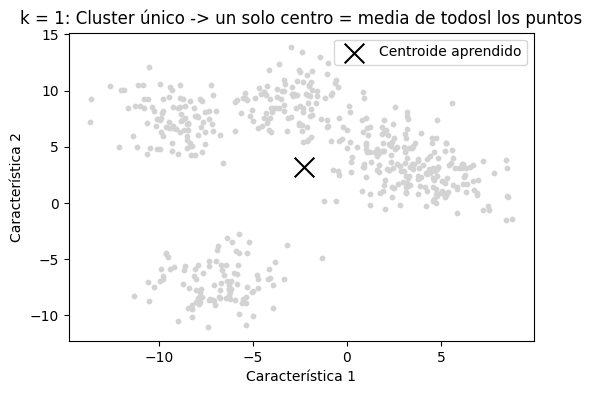

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(x[:, 0], x[:, 1], s=10, c="lightgray")
plt.scatter(
    kmeans_1.cluster_centers_[0, 0],
    kmeans_1.cluster_centers_[0, 1],
    c="black",
    s=200,
    marker="x",
    label="Centroide aprendido"
)

plt.title("k = 1: Cluster único -> un solo centro = media de todosl los puntos")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()

### 4.2 Qué significan `fit`, `predict` y `fit_predict`

- `fit(X)`: aprende centroides
- `predict(X_new)`: asigna puntos (viejos o nuevos) al centroide más cercano
- `fit_predict(X)`: atajo = `fit` + etiquetas de entrenamiento

Las etiquetas son **números arbitrarios** (0,1,2…): el cluster 0 no tiene un significado semántico por sí solo.



In [ ]:
kmeans_5 = KMeans(n_clusters=5, n_init = 10, random_state=42)
labels_5 = kmeans_5.fit_predict(x)
df_asig = pd.DataFrame(
    {
        "feat1": x[:, 0],
        "feat2": x[:, 1],
        "cluster_real": y,
        "cluster_kmeans": labels_5,
    }

)
print("Tamaño por cluster kmeas:\n")
print(df_asig["cluster_kmeans"].value_counts().sort_index().to_frame("n"))
print("Muestra de las asignaciones:\n")
print(df_asig.head(10))
print("Centroides:\n")
print(kmeans_5.cluster_centers_)
print("Inercia:", round(kmeans_5.inertia_, 2))
print("Iteraciones:", kmeans_5.n_iter_)

Tamaño por cluster kmeas:

                  n
cluster_kmeans     
0               104
1               100
2                95
3               102
4                99
Muestra de las asignaciones:

       feat1     feat2  cluster_real  cluster_kmeans
0   4.617835  0.358112             1               3
1   1.860776  6.753663             4               4
2  -0.282248  5.731875             4               4
3  -1.194402  0.129272             1               4
4 -10.247053 -7.512834             2               1
5   3.325219  2.362795             1               3
6  -4.777619 -6.422152             2               1
7   2.542804  8.580992             4               4
8  -1.976181  9.484186             0               0
9  -2.647981  9.628360             0               0
Centroides:

[[-2.862  9.035]
 [-6.882 -7.087]
 [-9.221  7.414]
 [ 4.956  1.778]
 [ 2.061  4.778]]
Inercia: 2724.93
Iteraciones: 9


### 4.3 Comparar clusters aprendidos vs verdad (cuando existe `y`)

Ojo: los IDs de cluster de KMeans **no tienen por qué coincidir** con los IDs de `y`.
Por eso usamos métricas como **Adjusted Rand Index (ARI)** que son invariantes a permutaciones de etiquetas.



In [ ]:
ari = adjusted_rand_score(y, labels_5)
hom = homogeneity_score(y, labels_5)
com = completeness_score(y, labels_5)
v_m = v_measure_score(y, labels_5)
print("ARI:", round(ari, 3))

print(f"ARI (Adjusted Rand Index): {ari:.3f} #1.0 = coincidencia perfecta (salvo permutacion)")
print(f"Homogenity: {hom:.3f}")
print(f"Completeness: {hom:.3f}")
print(f"V_measure: {v_m:.3f}")

#Matriz de contingencia: filas = real, columnas = kmeans

contingencia = pd.crosstab(
    df_asig["cluster_real"],
    df_asig["cluster_kmeans"],
    rownames=["real"],
    colnames=["kmeans"],
)
print("\nMatriz de contingencia:")
print(contingencia)

ARI: 0.819
ARI (Adjusted Rand Index): 0.819 #1.0 = coincidencia perfecta (salvo permutacion)
Homogenity: 0.844
Completeness: 0.844
V_measure: 0.845

Matriz de contingencia:
kmeans   0    1   2   3   4
real                       
0       98    0   1   0   1
1        0    0   0  84  16
2        0  100   0   0   0
3        6    0  94   0   0
4        0    0   0  18  82


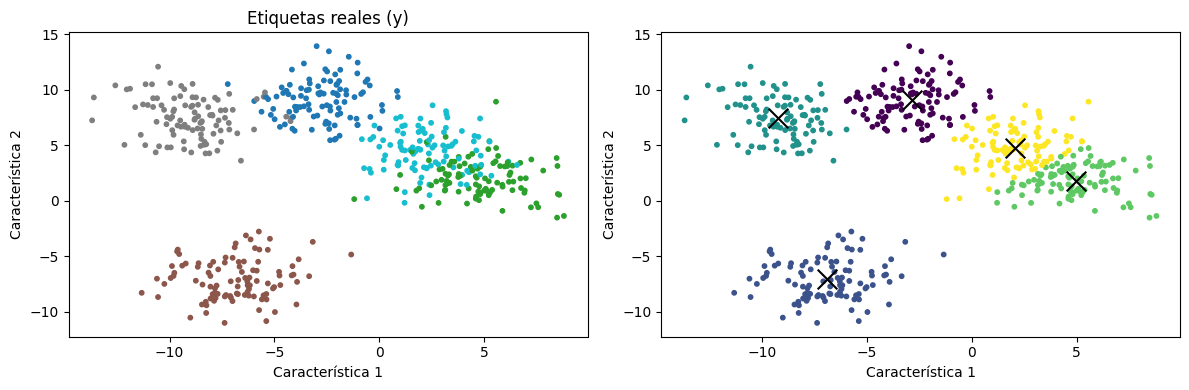

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(x[:, 0], x[:, 1], s=10, c=y, cmap='tab10')
axes[0].set_title("Etiquetas reales (y)")

axes[1].scatter(x[:, 0], x[:, 1], s=10, c=labels_5, cmap='viridis')
axes[1].scatter(
    kmeans_5.cluster_centers_[:, 0],
    kmeans_5.cluster_centers_[:, 1],
    c="black",
    s=200,
    marker="x",
    label="Centroide aprendido",
)

axes[1].set_xlabel("KMeans k = 5 | ARI= {ari:.3f}")

for ax in axes:
  ax.set_xlabel("Característica 1")
  ax.set_ylabel("Característica 2")

plt.tight_layout()
plt.show()



<a name="3b"></a>
## 5. Variando k: subajuste y sobreajuste de clusters

- `k` demasiado **chico**: mezcla grupos distintos (sub-segmentación).
- `k` demasiado **grande**: parte un mismo grupo en pedazos artificiales.
- `k` correcto (acá ≈ 5): debería alinear mejor con la estructura.



In [ ]:
ks_probar = [2, 3, 4, 5, 6, 8. 10]
fig, axes = plt.subplots(1, len(ks_probar), figsize=(12, 6))
axes = axes.ravel()
resumen_k = []

for ax, k in zip(axes, ks_probar):
  kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
  labs = km.fit_predict(x)
  ax.scatter(x[:,0], x[:,1], s=10, c=labs, cmap='viridis')
  ax.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], c='black', s=200, marker='x', label="Centroide aprendido")
  ax.set_title(f"k = {k} | inercia= {km.inertria-:.2f} | ARI={ari_k:.2f}")
  ax.set_xticks([])
  ax.set_yticks([])

  resumen_k.append({
      'k': k,
      'inercia': km.inertia_,
      'ari': ari_k,
      "n_inter": km.n_iter_,

  })

resumen_k = pd.DataFrame(resumen_k)
  resumen_k.aprend

### 5.1 Tabla detallada de asignaciones para varios k

Útil para ver cómo cambian las etiquetas de los mismos puntos.



<a name="4"></a>
## 6. Visualización de regiones de decisión

K-Means no solo etiqueta los puntos de entrenamiento: define una **partición del espacio**.

Para cualquier punto nuevo, la predicción es: *“¿a qué centroide estoy más cerca?”*.

Eso genera un diagrama tipo **Voronoi**.



### 6.1 Cómo se construye la grilla

1. Tomamos el rango de `X` (con un margen).
2. Armamos un `meshgrid` denso.
3. Predicimos el cluster de cada celda.
4. Pintamos con `contourf`.



### 6.2 Predicción de puntos nuevos (fuera de la muestra)

Imaginá que llegan 3 observaciones nuevas: K-Means las ubica en la región correspondiente.



<a name="5"></a>
## 7. Hiperparámetros en profundidad

### 7.1 `init`: `random` vs `k-means++`

- **`random`**: elige k puntos al azar como semillas (más chance de mala inicialización).
- **`k-means++`**: elige semillas más separadas ⇒ suele converger mejor/más rápido.

### 7.2 `n_init`

Como K-Means puede caer en **mínimos locales**, se reinicia varias veces y se queda con la mejor inercia.

### 7.3 `max_iter` y `tol`

Controlan el freno del loop asignación/actualización. En datasets chicos casi siempre converge antes de 300.



### 7.4 ¿Por qué a veces no se ve diferencia?

En `make_blobs` con grupos bien separados, casi cualquier inicialización razonable encuentra una solución parecida.
Para ver el efecto de `n_init`, necesitamos un caso **más ambiguo** (más solapamiento).



### 7.5 `max_iter` muy bajo: convergencia incompleta

Si cortamos el algoritmo demasiado pronto, los centroides pueden no estabilizarse.



<a name="6"></a>
## 8. Limitaciones con formas no esféricas: `make_moons`

Hasta ahora los datos eran “pelotas”. ¿Qué pasa con **lunas entrelazadas**?

K-Means corta el plano con fronteras basadas en distancia a centroides ⇒ **no puede** seguir una curvatura.



### 8.1 Regiones de decisión sobre moons

La visualización deja claro el corte “a la mitad” que hace K-Means.



### 8.2 Efecto del ruido

Más ruido ⇒ más solapamiento ⇒ todavía más difícil (para cualquier algoritmo, pero K-Means ya partía mal).



<a name="8"></a>
## 9. Más ejemplos prácticos (sección extendida)

Esta sección es el “laboratorio” de la clase. Cada subpunto incluye:
- explicación conceptual,
- código,
- interpretación de qué mirar en el gráfico,
- una pregunta guía.



### 9.1 Método del codo (Elbow) — en profundidad

**Inercia** = suma de distancias al cuadrado punto→su centroide.

Propiedades clave:
1. Baja (casi) monótonamente al subir `k`.
2. El “codo” es donde agregar un cluster más **ya no reduce mucho** la inercia.
3. Es una heurística visual: a veces el codo es claro, a veces no.

Pregunta guía: *¿el codo cae cerca de 5, que es el número real de centros?*



#### Interpretación

- Si el Δ inercia se desploma hasta k≈5 y después se achica, el codo “apunta” a 5.
- El ARI (cuando hay `y`) suele confirmarlo.
- En la vida real **no** tenés ARI: por eso combinás codo + silhouette + conocimiento de negocio.



### 9.2 Silhouette score — global y por punto

Para un punto $i$:
- $a(i)$: distancia media a puntos de su propio cluster
- $b(i)$: distancia media al cluster vecino más cercano
- $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$

Rango: **[-1, 1]**

| Valor | Lectura |
|---|---|
| cerca de 1 | bien asignado / compacto y separado |
| cerca de 0 | en el borde |
| negativo | probablemente en el cluster equivocado |

El **silhouette promedio** resume la calidad de toda la partición.



#### Diagrama de silhouette por muestra

Además del promedio, el gráfico por punto muestra:
- qué tan consistentes son los clusters,
- si hay muchos valores bajos/negativos (mala separación).



### 9.3 `make_circles`: anillo interior vs exterior

Otra geometría imposible para K-Means: un círculo dentro de otro.
Aunque `k=2` sea “correcto” en cantidad, la forma no es esférica ⇒ falla.



### 9.4 Clusters de distinto tamaño y densidad

K-Means tiende a crear clusters de **volúmenes parecidos**.  
Si un grupo es chico/denso y otro grande/disperso, los bordes pueden distorsionarse.



### 9.5 Efecto de la escala (muy importante en la práctica)

K-Means usa distancia euclídea. Si una variable está en **miles** y otra en **unidades**, la grande domina.

Regla práctica:
> Si las features tienen unidades distintas o rangos muy diferentes, **estandarizá** (`StandardScaler`) antes de K-Means.



#### Extra: ¿qué pasa si MinMax en vez de z-score?

`StandardScaler` (media 0, std 1) suele ser el default razonable para K-Means.  
Podés comparar con un escalado lineal a [0,1].



### 9.6 Clusters alargados (anisotropía)

Si los grupos son elípticos/rotados, la distancia euclídea isotrópica de K-Means puede cortar mal.



### 9.7 Panel comparativo: un mismo flujo de evaluación

Idea de trabajo profesional / de laboratorio:

1. Generar (o cargar) datos  
2. Estandarizar si hace falta  
3. Barrer `k`  
4. Mirar inercia + silhouette (+ ARI si hay labels)  
5. Inspeccionar gráficos, no solo números



### 9.8 Mini laboratorio / desafíos

Completá / modificá las celdas siguientes. No hay una única respuesta: lo importante es **observar y explicar**.

**Desafío A — Codo con otro número de centros**  
Regenerá blobs con `centers=4` y mirá si el codo/silhouette se mueven.

**Desafío B — Circles con más ruido**  
Subí `noise` a `0.15` y compará ARI/silhouette.

**Desafío C — Escala**  
Aumentá la diferencia de ingresos entre grupos hasta que KMeans sin scaler empiece a funcionar. ¿Por qué?

**Desafío D (bonus)** — 3 features  
Generá blobs en 3D y visualizá con scatter 3D + KMeans.



<a name="lab"></a>
## 10. Laboratorio extendido — más ejemplos para practicar

En esta parte vamos a **ralentizar** el algoritmo, romperlo a propósito y aplicarlo a escenarios distintos.
La idea es construir intuición: no solo “correr `KMeans`”, sino **entender qué está pasando**.



### 10.1 K-Means “a mano”: ver las iteraciones

Vamos a implementar una versión didáctica (no optimizada) y dibujar **asignación → actualización** paso a paso.



#### Preguntas para discutir en clase
1. ¿Los centroides se mueven mucho al principio y poco al final? ¿Por qué?
2. ¿La inercia siempre baja entre iteraciones?
3. ¿Qué pasaría si un cluster se queda vacío en alguna iteración?



### 10.2 Misma data, distintas semillas de inicialización

Aunque `n_init` mitiga el problema, es útil **ver** cómo cambia el resultado con una sola corrida (`n_init=1`) y distintas semillas.



### 10.3 Outliers: cómo rompen los centroides

K-Means usa **medias**. Un outlier extremo arrastra el centroide y puede deformar un cluster entero.



#### Mini práctica
Agregá vos 2 outliers en otras coordenadas y volvé a fittear. ¿Qué cluster “se come” el outlier?



### 10.4 Distancia al centroide: ¿qué tan “seguro” está cada punto?

Podemos medir la distancia de cada punto a su centroide. Puntos lejanos = borde / posible outlier / mala asignación.



### 10.5 ¿Cuántos clusters “se ven”? Comparar 3 datasets lado a lado

Mismo pipeline, distinta geometría. Anotá en voz alta qué `k` elegirías **antes** de mirar métricas.



### 10.6 Cuantización de colores (ejemplo visual clásico)

K-Means también se usa para **comprimir** una imagen reduciendo la cantidad de colores a `k` centroides en RGB.

> Si no tenés imagen local, generamos una imagen sintética de manchas de color.



### 10.7 Perfilado de clusters (interpretar centroides)

En un caso real, después de clusterizar miramos **qué significa** cada grupo: medias de features, tamaños, ejemplos.



### 10.8 Estabilidad: ¿el clustering se mantiene si subsampleamos?

Idea: si al tomar muestras distintas los clusters cambian mucho, la estructura es frágil.



### 10.9 k incorrecto a propósito: story-telling de errores

Forzamos `k` malo y describimos el síntoma visual típico.



<a name="clasicos"></a>
## 11. Datasets clásicos: Iris y Wine

Hasta ahora casi todo fue sintético. Ahora aplicamos el **mismo flujo** a datasets reales de scikit-learn.



### 11.1 Iris (4 features)

Iris tiene 3 especies. K-Means no ve las etiquetas: ¿recupera algo parecido?
Como hay 4 dimensiones, para visualizar usamos las 2 primeras features (y también PCA rápido opcional).



### 11.2 Wine (13 features)

Más features ⇒ más crítico estandarizar. Compará resultados con y sin scaler.



<a name="negocio"></a>
## 12. Caso de negocio: segmentación de clientes (sintético)

Simulamos un e-commerce con features típicas. El objetivo no es “acertar etiquetas” (no hay), sino **obtener segmentos accionables**.



### 12.1 ¿Qué pasa si NO escalamos en el caso de negocio?

La `recencia_dias` y el `ticket` pueden dominar. Comparemos.



<a name="ejercicios"></a>
## 13. Ejercicios integradores

Trabajá en orden. Si te trabás, volvé a la sección teórica correspondiente.

### Ejercicio 1 — Diagnóstico visual
Generá blobs con `centers=6`, `cluster_std=2.5`. Sin mirar `y`:
1. Dibujá el scatter.
2. Estimá `k` a ojo.
3. Confirmá con codo + silhouette.
4. Calculá ARI solo al final.



### Ejercicio 2 — Moons vs blobs: misma métrica, distinta verdad

Entrená KMeans k=2 en moons y en blobs de 2 centros. Compará silhouette y ARI.  
¿En qué caso silhouette “engaña”?



### Ejercicio 3 — Pipeline completo sobre Wine

1. Escalá.
2. Elegí `k` con silhouette.
3. Fitteá.
4. Mostrá matriz de contingencia vs `y`.
5. Describí en 2 oraciones si el clustering “sirve”.



### Ejercicio 4 — Diseño de experimento

Completá la tabla mental (y si querés, código):

| Situación | ¿KMeans conviene? | ¿Qué harías antes? | ¿Qué mirarías después? |
|---|---|---|---|
| Clientes con features en distintas unidades | | | |
| Datos en forma de anillo | | | |
| 3 grupos claros gaussianos | | | |
| Muchos outliers de sensores | | | |

Implementá al menos **una** fila como experimento reproducible abajo.



### Ejercicio 5 — Challenge abierto (para el final)

Generá tu propio dataset (con `make_blobs` o datos inventados en NumPy) que cumpla **una** de estas condiciones:

A. Codo claro en k=3 pero silhouette prefiere k=4  
B. Sin scaler ARI < 0.3 y con scaler ARI > 0.8  
C. Visualmente 2 grupos, pero KMeans k=2 obtiene ARI < 0.5  

Documentá parámetros y mostrá gráficos.



### 13.1 Soluciones parciales / pistas (mirar solo si hace falta)

**Ejercicio 2:** en moons, silhouette puede ser moderado/aceptable mientras ARI es bajo: la métrica interna no ve la geometría “luna”.

**Ejercicio 3:** en Wine, silhouette suele votar cerca de k=3; ARI con scaler debería ser claramente mejor que sin scaler.

**Ejercicio 5B:** repetí el ejemplo edad/ingreso exagerando la diferencia de escalas.

**Ejercicio 5C:** `make_moons` o `make_circles` con `k=2`.



<a name="7"></a>
## 14. Cheatsheet y reflexión final

### Cheatsheet rápido

| Pregunta | Respuesta corta |
|---|---|
| ¿Qué optimiza K-Means? | Inercia (WCSS) |
| ¿Qué hiperparámetro es `k`? | `n_clusters` |
| ¿Cómo inicializar? | Preferir `k-means++` + `n_init` ≥ 10 |
| ¿Cómo elegir `k`? | Codo + silhouette (+ negocio) |
| ¿Escalar? | Sí, si features tienen escalas distintas |
| ¿Cuándo falla? | Lunas, anillos, elipses, densidades muy distintas, outliers fuertes |
| ¿Cómo validar sin labels? | Perfiles, estabilidad, utilidad de negocio |
| ¿Alternativa próxima clase? | DBSCAN (formas libres + outliers) |

### Checklist antes de usar K-Means en un dataset real

1. ¿Las features son numéricas (o ya encodeadas con cuidado)?
2. ¿Estandaricé / normalicé?
3. ¿Probé un rango de `k` y miré codo + silhouette?
4. ¿Inspeccioné los clusters (perfiles, tamaños, ejemplos)?
5. ¿Miré sensibilidad a outliers / semillas?
6. ¿El resultado es accionable para el problema de negocio?

### Reflexión

- K-Means es **simple, rápido y muy usado**.
- Brilla con grupos **compactos y aproximadamente esféricos**.
- No es un martillo universal: la geometría de los datos manda.
- Elegir `k` es parte del modelado, no un detalle menor.
- Las métricas ayudan, pero **no reemplazan** inspección visual e interpretación.
- En la próxima clase: **DBSCAN**, pensado para estructuras irregulares y ruido.

> Elegir el algoritmo adecuado siempre depende de **entender los datos**.



### Cierre — preguntas para llevarte

1. Si el codo sugiere k=4 y silhouette sugiere k=6, ¿qué harías?
2. ¿Por qué ARI alto no es usable en producción sin labels?
3. ¿Qué riesgo tiene interpretar clusters sin mirar las features originales?
4. ¿En qué caso NO estandarizarías antes de K-Means?
5. ¿Cómo explicarías a alguien de negocio qué es un centroide?
6. Si un cluster tiene 5% de los datos y otro 60%, ¿automáticamente está mal?

¡Fin de la clase de K-Means!

